In [ ]:
import torch
import matplotlib.pyplot as plt
import pickle
import gzip
import seaborn as sns
from adjustText import adjust_text
from tqdm import tqdm
import itertools
import os
import pandas as pd

# Expose GPU 0 to CUDA/PyTorch (change "0" if needed)
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(device)

torch.no_grad().__enter__()

cuda


In [3]:
from transformers import AutoConfig, AutoModel, AutoTokenizer

model_id = "cross-encoder/ms-marco-MiniLM-L12-v2"
config = AutoConfig.from_pretrained(model_id)
model = AutoModel.from_pretrained(model_id).to(device)
tokenizer = AutoTokenizer.from_pretrained(model_id)
model.to(device)
model.eval()

NUM_HEADS = config.num_attention_heads
NUM_LAYERS = config.num_hidden_layers
HIDDEN_DIM = config.intermediate_size
D_H = model.config.hidden_size  // model.config.num_attention_heads

print(f"NUM_HEADS: {NUM_HEADS}, NUM_LAYERS: {NUM_LAYERS}, HIDDEN_DIM: {HIDDEN_DIM}, HEAD_DIM: {D_H}")

/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


NUM_HEADS: 12, NUM_LAYERS: 12, HIDDEN_DIM: 1536, HEAD_DIM: 32


In [4]:
from notebooks.utils import LayerHook, process_attention

hooks = []
for ix, layer in enumerate(model.encoder.layer):
    hook = LayerHook(ix)
    handle = layer.register_forward_pre_hook(hook)
    hook.handle = handle
    hooks.append(hook)

In [5]:
default_label_kwargs = {
    'fontsize': 12,
    'color': 'black',
    # 'fontweight': 'bold'
}

# ALL

In [6]:
datasets_to_parsed_file = {
    "irds.msmarco-passage.trec-dl-2019.judged": "/home/vast/target_dir/relevance-integrations/jobs/src.evd.utils.diversepassagessamplerwithhardnegatives/1f6b16d86e837585252bbf4060c8fbed8e68e56a4b72e30ee42acc685f918a43/dataset.tsv",
    "irds.msmarco-passage.trec-dl-2020.judged": "/home/vast/target_dir/relevance-integrations/jobs/src.evd.utils.diversepassagessamplerwithhardnegatives/a8585c12debebe600293e8db3f0252a22513da7e18c1258637415c78c1d25e6e/dataset.tsv",
    "irds.msmarco-passage-v2.trec-dl-2021.judged": "/home/vast/target_dir/relevance-integrations/jobs/src.evd.utils.diversepassagessamplerwithhardnegatives/f4bf320a12daf1f16bc675c32e9af0fb5b61734b634097a8e293282ca61bc58f/dataset.tsv",
    "irds.msmarco-passage-v2.trec-dl-2022.judged": "/home/vast/target_dir/relevance-integrations/jobs/src.evd.utils.diversepassagessamplerwithhardnegatives/7e566277a795074c267f7d74cddc2173d5bb56ffd50c565cdc1aba933b0037ab/dataset.tsv",
    "irds.beir.fiqa.test": "/home/vast/target_dir/relevance-integrations/jobs/src.evd.utils.diversepassagessamplerwithhardnegatives/5f77a9ad4363f5bb7b97ace9abccf282ce4ffe13675f9e8e9061ccb345c5236b/dataset.tsv",
    "irds.beir.trec-covid": "/home/vast/target_dir/relevance-integrations/jobs/src.evd.utils.diversepassagessamplerwithhardnegatives/244cfde19bcb3e444859decee450b4161e0176687edaaebcbdd6bf3d78694629/dataset.tsv",
    "irds.beir.nfcorpus.test": "/home/vast/target_dir/relevance-integrations/jobs/src.evd.utils.diversepassagessamplerwithhardnegatives/e31fddadaeef616b9459c88f5c5653161d1baec720b73763e8a9a18f501f5d45/dataset.tsv",
    "irds.disks45.nocr.trec-robust-2004": "/home/vast/target_dir/relevance-integrations/jobs/src.evd.utils.diversepassagessamplerwithhardnegatives/476c78b26d9e0d5f1c441f43f1218beff7316ae0006cbf5a3c5e281942bd2763/dataset.tsv",
    "irds.dpr-w100.natural-questions.dev": "/home/vast/target_dir/relevance-integrations/jobs/src.evd.utils.diversepassagessamplerwithhardnegatives/9e6934c710ad9de540222cb16052051f34239397e77fc3a0c5e8161ac8bf767f/dataset.tsv",
    "irds.beir.bioasq.test": "/home/vast/target_dir/relevance-integrations/jobs/src.evd.utils.diversepassagessamplerwithhardnegatives/4b17bf286985501ac420d88d9183c85b3af1cceeed777058d6355616edd49dba/dataset.tsv"
}

In [ ]:
attention_file = "/home/vast/target_dir/relevance-integrations/jobs/src.evd.attention_patterns.summarizeattentionpatterns/f19b3d60452cf7db4068b6b48633db6a7d5ca95899fd5332a70e7ff0be2b6a1f/dataframes/"
with gzip.open(attention_file + "/attention.pkl.gz", "rb") as fp:
    try:
        data = pickle.load(fp)    
    except ModuleNotFoundError as e:
        print(f"Missing module: {e.name}")

data.head()
rel_map = {"weak_negative": -1, "non_relevant": 0, "relevant": 1}
data["rel"] = data["rel"].map(rel_map)

with gzip.open(attention_file + "/attention_duplicate_token.pkl.gz", "rb") as fp:
    data_duplicate = pickle.load(fp)    

data_duplicate.rename(columns={"q2d": "dup_q2d", "d2q": "dup_d2q"}, inplace=True)
data_duplicate["rel"] = data_duplicate["rel"].map(rel_map)

with gzip.open(attention_file + "/attention_entropy.pkl.gz", "rb") as fp:
    data_entropy = pickle.load(fp)    

data_entropy.rename(columns={"q2d": "ent_q2d", "d2q": "ent_d2q"}, inplace=True)
data_entropy["rel"] = data_entropy["rel"].map(rel_map)

data_by_query = process_attention(data, data_duplicate, data_entropy)

# Aggregate over queries
medians = data_by_query.groupby(["layer", "head"]).median(numeric_only=True).reset_index()

q2d_max = medians.sort_values(by="q2d_delta_weak", ascending=False)
d2q_max = medians.sort_values(by="d2q_delta_weak", ascending=False)

In [8]:
from datamaestro import prepare_dataset
from datamaestro_text.data.ir import TextItem, IDItem

import ir_datasets

queries = {}
allqrels = {}
docs = {}
assessed_queries = set()
assessed_docs = set()
count = 0

for dataset_name, file_path in datasets_to_parsed_file.items():
    dataset = prepare_dataset(dataset_name)
    with open(file_path, "r") as f:
        for line in f:
            count += 1
            parts = line.strip().split('\t')
            if len(parts) < 4:
                print("skipped")
                continue  # skip malformed lines
        
            query_id = parts[0]
            queries[query_id] = dataset.topics.topic_ext(query_id)  
            assessed_queries.add(query_id)

            positives = parts[2].split()
            negatives = parts[4].split()
            
            for doc_id in positives:
                assessed_docs.add(doc_id)
                docs[doc_id] = dataset.documents.document_ext(doc_id)
                allqrels.setdefault(query_id, []).append(ir_datasets.formats.trec.TrecQrel(
                    query_id, doc_id, 3, None)
                )

            for doc_id in negatives:
                assessed_docs.add(doc_id)
                docs[doc_id] = dataset.documents.document_ext(doc_id)
                allqrels.setdefault(query_id, []).append(ir_datasets.formats.trec.TrecQrel(
                    query_id, doc_id, 0, None)
                )

[INFO] Opening /home/vast/.ir_datasets/msmarco-passage/collection.tsv.pklz4/bin with MMAP
[INFO] Opening /home/vast/.ir_datasets/msmarco-passage/collection.tsv.pklz4/bin with MMAP
[INFO] Opening /home/vast/.ir_datasets/msmarco-passage-v2/msmarco_v2_passage.tar.pklz4/bin with MMAP
[INFO] Opening /home/vast/.ir_datasets/msmarco-passage-v2/msmarco_v2_passage.tar.pklz4/bin with MMAP
[INFO] Opening /home/vast/.ir_datasets/beir/fiqa/docs.pklz4/bin with MMAP
[INFO] Opening /home/vast/.ir_datasets/beir/trec-covid/docs.pklz4/bin with MMAP
[INFO] Opening /home/vast/.ir_datasets/beir/nfcorpus/docs.pklz4/bin with MMAP
[INFO] Opening /home/vast/.ir_datasets/disks45/corpus.nocr.pklz4/bin with MMAP
[INFO] Opening /home/vast/.ir_datasets/dpr-w100/docs.tsv.gz.pklz4/bin with MMAP
[INFO] Opening /home/vast/.ir_datasets/beir/bioasq/docs.pklz4/bin with MMAP


In [9]:
# Computes the mean input at each layer

# Uses a uniform distribution over queries, and over relevance levels 

q_means = torch.zeros((NUM_LAYERS, model.config.hidden_size)).to(device)
d_means = torch.zeros((NUM_LAYERS, model.config.hidden_size)).to(device)
qrel_items = list(allqrels.items())

query_weight = 1./len(qrel_items)

n_docs = len(docs.keys())
count = 0
for query_id, qrels in tqdm(qrel_items):    
    query = queries[query_id]
    
    counts = torch.zeros(5)
    for qrel in qrels:
        counts[qrel.relevance] += 1

    # Adds random documents
    counts[-1] = int(counts.sum() / 4)
    weak_qrels = []
    selected = torch.randint(low=0, high=n_docs, size=(int(counts[-1]),))
    for doc_ix in selected:
        weak_qrels.append(ir_datasets.formats.trec.TrecQrel(
            None, list(docs.keys())[doc_ix], -1, None
        ))
    
    weights = query_weight / counts / (counts > 0).sum()
    
    for qrel in tqdm(itertools.chain(qrels, weak_qrels), total=int(counts.sum()), leave=False):
        doc = docs[qrel.doc_id]
        inputs = tokenizer([[query[TextItem].text, doc[TextItem].text]], max_length=128, return_tensors='pt').to(device)
        outputs = model(**inputs, output_attentions=False)

        # Find first document token ID
        tokens = tokenizer.convert_ids_to_tokens(inputs.input_ids[0])
        doc_ix = (inputs.token_type_ids == 1).nonzero()[0][-1].item()
        for hook in hooks:
            x_q = hook.hidden_states[0, 1:doc_ix-1, :].mean(0)
            x_d = hook.hidden_states[0, doc_ix:, :].mean(0)

            q_means[hook.layer_ix] += weights[qrel.relevance] * x_q
            d_means[hook.layer_ix] += weights[qrel.relevance] * x_d        

100%|██████████| 705/705 [06:17<00:00,  1.87it/s]


In [10]:
def get_head_svd(A, d_h=64, non_zero=True):
    U, S, Vh = torch.linalg.svd(A, full_matrices=False)

    if sum(S) > 1e-4:
        error = S[d_h:].sum() / sum(S)
        assert error < 1e-4, f"Error {error} = {S[64:].sum()} / {sum(S)}"

    U = U[..., :d_h]
    Vh = Vh[:d_h]
    S = S[:d_h]

    if non_zero:
        non_zero_ix = S > 1e-4
        U = U[:, non_zero_ix]
        S = S[non_zero_ix]
        Vh = Vh[non_zero_ix]
    return U, S, Vh


In [12]:
def get_qk(model, layer_ix, head_ix, d_h=64):
    sa = model.encoder.layer[layer_ix].attention.self
    query_weight =  sa.query.weight
    key_weight =  sa.key.weight
    

    r = range(head_ix*d_h, (head_ix+1)*d_h)
    return query_weight[r], key_weight[r] 


class HeadStatistics:
    def __init__(self, layer_ix: int, head_ix: int):        
        self.layer_ix = layer_ix
        self.head_ix = head_ix
        
        query_weight =  model.encoder.layer[layer_ix].attention.self.query.weight
        key_weight =  model.encoder.layer[layer_ix].attention.self.key.weight
        
        w_q, w_k = get_qk(model, layer_ix, head_ix, D_H)

        self.Ah = Ah = w_q.T @ w_k
        
        U, S, Vh = self.U, self.S, self.Vh = get_head_svd(Ah, d_h=D_H)
        # Inner product between $u_i$ and $v_i$
        inners = (Vh.unsqueeze(1) @ U.T.unsqueeze(-1)).squeeze() / U.norm(dim=0) / Vh.norm(dim=1)
        
        q_mean = q_means[layer_ix]
        d_mean = d_means[layer_ix]
        
        qu_cos = (q_mean @ U / q_mean.norm() / U.norm(dim=0))
        qv_cos = (Vh @ q_mean / q_mean.norm() / Vh.norm(dim=1))
        
        du_cos = (d_mean @ U / d_mean.norm() / U.norm(dim=0))
        dv_cos = (Vh @ d_mean / d_mean.norm() / Vh.norm(dim=1))
        
        df = pd.DataFrame({
            "q_u": qu_cos.cpu(),
            "q_v": qv_cos.cpu(),
            "d_u": du_cos.cpu(),
            "d_v": dv_cos.cpu(),
            "inner": inners.cpu(),
            "s": S.cpu() 
        })
        df["n_s"] = df.s / df.s.max()

        self.df = df
        self.inner_p_sum = (torch.nn.functional.relu(inners) * S).sum()


hs = []
for layer_ix in tqdm(range(NUM_LAYERS)):
    hs_layer = []
    hs.append(hs_layer)
    
    for head_ix in tqdm(range(model.config.num_attention_heads), leave=False):
        hs_layer.append(HeadStatistics(layer_ix, head_ix))

100%|██████████| 12/12 [00:11<00:00,  1.07it/s]


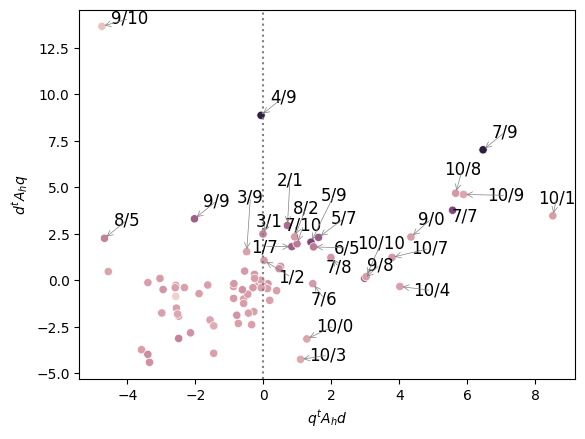

In [13]:
inner_threshold = 0.3
threshold = 0.3

data = []
for layer_ix, hs_layer in enumerate(hs):   
    for head_ix, hs_head in enumerate(hs_layer):
        h = hs_head
        q = q_means[h.layer_ix]
        d = d_means[h.layer_ix]
        qAd = float(q @ h.Ah @ d - d @ h.Ah @ d)
        dAq = float(d @ h.Ah @ q - q @ h.Ah @ q)
        ix = h.df.inner > inner_threshold
        inner_p_sum = (h.df.inner[ix] * h.S[ix].cpu().numpy()).sum()
        data.append([layer_ix, head_ix, float(inner_p_sum), qAd, dAq])
df_inner_p = pd.DataFrame(data, columns=["layer", "head", "inner", "qAd", "dAq"])

df_all = df_inner_p.merge(q2d_max)
df_all = df_all[df_all.dAq > -5]
ax = sns.scatterplot(df_all, y="dAq", x="qAd", hue="q2d_delta_weak")
                   

texts = []
for point in df_all.itertuples():
    if point.dAq > 1 or point.qAd > 1:
        text = plt.text(point.qAd, point.dAq, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
        texts.append(text)
if texts:
    adjust_text(texts, force_explode=2, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5), expand_points=(2, 2))

plt.axvline(x=0, color='gray', linestyle='dotted');
ax.legend_.remove()  # Removes the legend
ax.set_xlabel(r"$q^t A_h d$");
ax.set_ylabel(r"$d^t A_h q$");
plt.show()

In [14]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['text.usetex'] = False

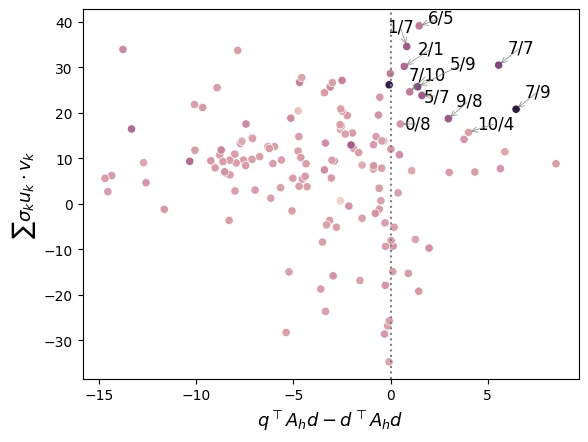

In [15]:
inner_threshold = 0
threshold = 0.3

data = []
for layer_ix, hs_layer in enumerate(hs):   
    for head_ix, hs_head in enumerate(hs_layer):
        h = hs_head
        q = q_means[h.layer_ix]
        d = d_means[h.layer_ix]
        delta_q = float(d @ h.Ah @ q - q @ h.Ah @ q)
        delta_d = float(q @ h.Ah @ d - d @ h.Ah @ d)
        # ix = h.df.inner > inner_threshold
        inner_p_sum = (h.df.inner * h.S.cpu().numpy()).sum()
        data.append([layer_ix, head_ix, float(inner_p_sum), delta_q, delta_d])
df_inner_p = pd.DataFrame(data, columns=["layer", "head", "inner", "delta_q", "delta_d"])

inner_threshold = 0.
threshold = 0.3

df_all_q2d = df_inner_p.merge(q2d_max)
df_all_q2d = df_all_q2d[df_all_q2d.delta_d > -20]
ax = sns.scatterplot(df_all_q2d, y="inner", x="delta_d", hue="q2d_delta_weak")

texts = []
for point in df_all_q2d.itertuples():
    if point.inner > 15 and point.delta_d > 0.01:
        text = plt.text(point.delta_d, point.inner, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
        texts.append(text)

if texts:
    adjust_text(texts, force_explode=1, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5), expand_points=(2, 3))

plt.axvline(x=0, color='gray', linestyle='dotted');
# plt.xlim(-.25,.25)
ax.legend_.remove()  # Removes the legend
ax.set_ylabel(r"$\sum \sigma_k u_k \cdot v_k$", fontsize=13);
ax.set_xlabel(r"$q^\top A_h d - d^\top A_h d$", fontsize=13);
# ax.figure.savefig(f"./matching_heads_{model_id}_msmarco_delta_d_q2d.pdf")
plt.show()

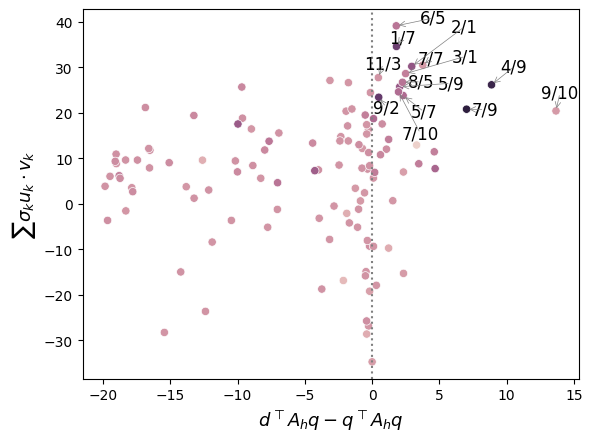

In [16]:
df_all_d2q = df_inner_p.merge(d2q_max)
df_all_d2q = df_all_d2q[df_all_d2q.delta_q > -20]
ax = sns.scatterplot(df_all_d2q, y="inner", x="delta_q", hue="d2q_delta_weak")

texts = []
for point in df_all_d2q.itertuples():
    if point.inner > 20 and point.delta_q > 0.01:
        text = plt.text(point.delta_q, point.inner, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
        texts.append(text)

if texts:
    adjust_text(texts, force_explode=1, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5), expand_points=(2, 3))

plt.axvline(x=0, color='gray', linestyle='dotted');
# plt.xlim(-.25,.25)
ax.legend_.remove()  # Removes the legend
ax.set_ylabel(r"$\sum \sigma_k u_k \cdot v_k$", fontsize=13);
ax.set_xlabel(r"$d^\top A_h q - q^\top A_h q$", fontsize=13);
# ax.figure.savefig(f"./matching_heads_{model_id}_msmarco_delta_q_d2q.pdf")
plt.show()